In [1]:
# importar as bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt




## Fase 1: Análise Exploratória (EDA) 

1 - Apresente as dimensões do dataset (número de linhas e colunas), os tipos de dados das variáveis e o resumo estatístico descritivo das colunas numéricas via método “.describe()”. 

2 - Plote, no mínimo, 3 gráficos analíticos bem fundamentados utilizando 
bibliotecas como Matplotlib ou Seaborn (Ex: histograma de distribuição das 
variáveis preditoras, gráfico de barras comprovando a taxa de desbalanceamento da variável alvo e um mapa de calor com a correlação de Pearson entre as variáveis). 

3 - Insira uma célula de texto analisando os valores numéricos e os padrões identificados nos gráficos, explicitando como eles direcionam a estratégia de modelagem. 

In [2]:
# abrir o dataframe e atribuir na variavel "df"
df = pd.read_csv("manutencao_preditiva.csv")


In [3]:
df.head()

# primeira visao do dataframe

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [4]:

df. shape  

# mostra o tamanho do dataframe, ou seja, 10.000 linhas e 14 colunas

(10000, 14)

In [5]:
df.info()

# Mostra resumo das informações gerais: colunas, tipos de dados e valores nulos (comando "df.info")
# no caso do dataframe do projeto, ele tem 14 colunas e 10.000 linhas (comando  "df.shape")
# sendo que 4 colunas possuem dados nulos 


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8), str(2)
me

In [6]:
df.isnull(). sum()

# Verifica valores vazios
# no caso tem 4 colunas com 500 linhas com elementos vazios em cada uma

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

In [7]:
df.describe()
# mostra Estatísticas das colunas numéricas (media, desvio padrao, mediana, min, max, quartis)

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Fase 2: Limpeza e Tratamento de Dados (Data Prep)

1 - Identifique e remova as linhas duplicadas. 

2 - Identifique dados ausentes e aplique a imputação por Média ou Mediana, 
justificando textualmente a escolha com base na distribuição dos dados. 

3 - Gere gráficos do tipo boxplot para identificar a presença de outliers nas 
variáveis explicativas. 

In [8]:
# apos uma visualzação inicial, optei por criar um novo dataframe 'df_tratado' e fiz uma copia do 'df' original 
# caso precise resgatar informacoes ou voltar para original

# DataFrame original
df

# Criar uma cópia para tratamento e chama-la de 'df_tratado'
df_tratado = df.copy()


In [9]:
## Remover colunas que não agregam informação
# como o projeto quer identificar falha essas duas colunas nao interferem
## 'udi' e 'id_produto'

df_tratado.drop(columns= ["udi"], inplace=True)
df_tratado.drop(columns= ["id_produto"], inplace=True)


In [10]:
# procurar dados duplicados

df_tratado.duplicated().sum()

np.int64(185)

In [11]:
# visualizar as linhas duplicadas

duplicados = df_tratado[df_tratado.duplicated()]

duplicados

,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
733,M,NaN,NaN,NaN,NaN,165,0,0,0,0,0,0
735,L,NaN,NaN,NaN,NaN,173,0,0,0,0,0,0
765,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
795,L,NaN,NaN,NaN,NaN,84,0,0,0,0,0,0
856,L,NaN,NaN,NaN,NaN,20,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9731,L,NaN,NaN,NaN,NaN,149,0,0,0,0,0,0
9733,M,NaN,NaN,NaN,NaN,153,0,0,0,0,0,0
9753,L,NaN,NaN,NaN,NaN,203,0,0,0,0,0,0
9783,H,NaN,NaN,NaN,NaN,66,0,0,0,0,0,0


In [12]:
# remover os duplicados

df_tratado = df_tratado.drop_duplicates()

In [13]:
# visualizacao apos dados duplicados removidos

df_tratado.duplicated().sum()

np.int64(0)

In [14]:
df_tratado.isnull(). sum()

tipo                         0
temperatura_ar_k           315
temperatura_processo_k     315
velocidade_rotacao_rpm     315
torque_nm                  315
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

In [15]:
# converter a coluna "tipo" de str para numerica

df_tratado = pd.get_dummies(
    df_tratado,
    columns=["tipo"],
    dtype=int
)

In [16]:
#visualizar df_tratado e conferir se apareceu a coluna "tipo" como numerica
df_tratado.info()


<class 'pandas.DataFrame'>
Index: 9815 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperatura_ar_k         9500 non-null   float64
 1   temperatura_processo_k   9500 non-null   float64
 2   velocidade_rotacao_rpm   9500 non-null   float64
 3   torque_nm                9500 non-null   float64
 4   desgaste_ferramenta_min  9815 non-null   int64  
 5   falha_maquina            9815 non-null   int64  
 6   falha_twf                9815 non-null   int64  
 7   falha_hdf                9815 non-null   int64  
 8   falha_pwf                9815 non-null   int64  
 9   falha_osf                9815 non-null   int64  
 10  falha_rnf                9815 non-null   int64  
 11  tipo_H                   9815 non-null   int64  
 12  tipo_L                   9815 non-null   int64  
 13  tipo_M                   9815 non-null   int64  
dtypes: float64(4), int64(10)
memory usage: 1

In [17]:
# revisao de dados nulos, pois apos apagar os dados duplicados, o dataframe ficom com 315 nulos

df_tratado.isnull().sum()

temperatura_ar_k           315
temperatura_processo_k     315
velocidade_rotacao_rpm     315
torque_nm                  315
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
tipo_H                       0
tipo_L                       0
tipo_M                       0
dtype: int64

In [18]:
# considerando os dados nulos em 4 colunas (São ainda 315 valores nulos)
# preencher dados nulos com a mediana pois ela é menos sensivel aos valores extremos

for coluna in [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm"
]:
    df_tratado[coluna] = df_tratado[coluna].fillna(df[coluna].median())

In [19]:
# consulta dados nulos apos a inclusao da mediana

df_tratado.isnull(). sum()

temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
tipo_H                     0
tipo_L                     0
tipo_M                     0
dtype: int64

In [20]:
df_tratado.head()

,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,tipo_H,tipo_L,tipo_M
0,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0,0,0,1
1,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0,0,1,0
2,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0,0,1,0
3,300.1,310.1,1504.0,40.1,7,0,0,0,0,0,0,0,1,0
4,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0,0,1,0


In [21]:
df_tratado.shape

(9815, 14)

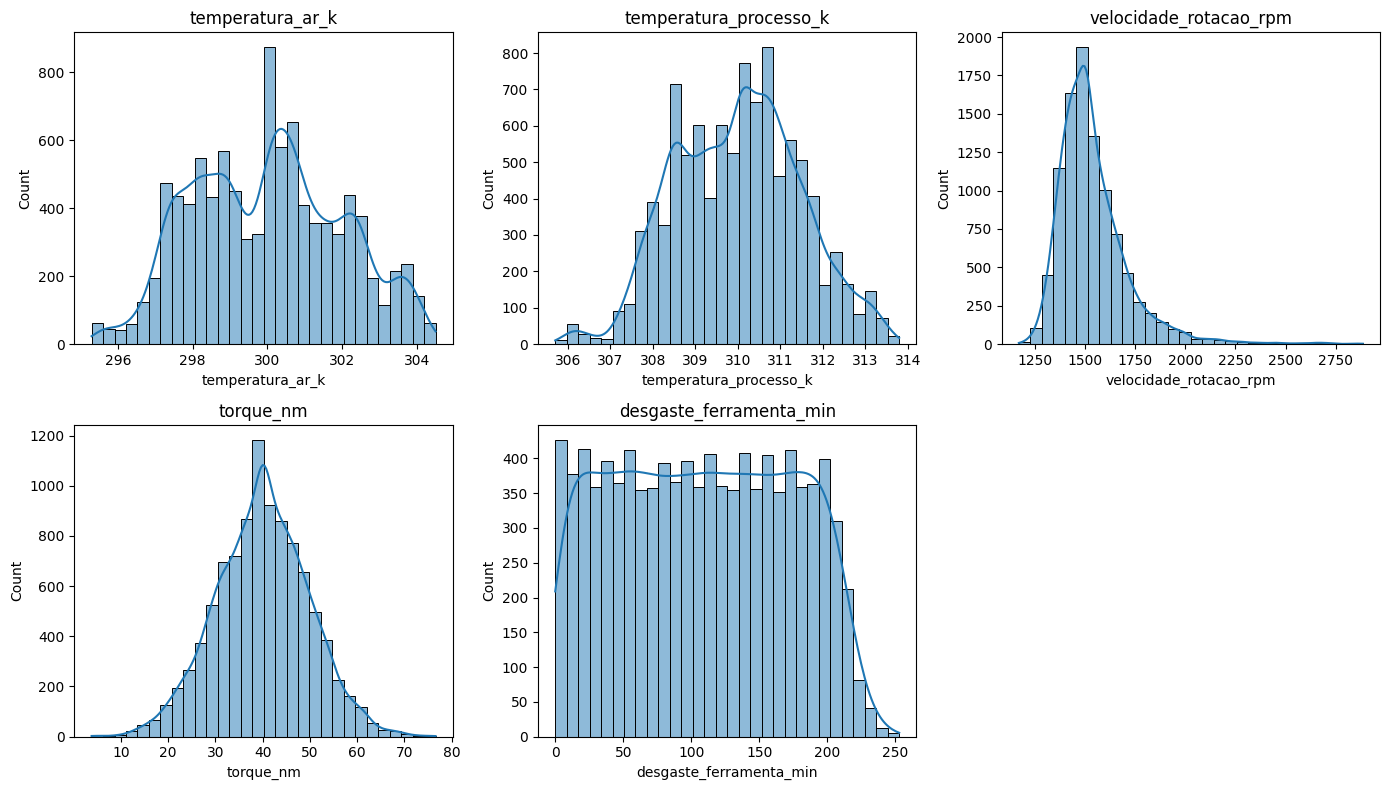

In [22]:
# Histograma das variáveis preditoras
# analisar a distribuição dos dados, identificar assimetrias e possíveis outliers

variaveis = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

plt.figure(figsize=(14,8))

for i, coluna in enumerate(variaveis):
    plt.subplot(2,3,i+1)
    sns.histplot(df_tratado[coluna], bins=30, kde=True)
    plt.title(coluna)

plt.tight_layout()
plt.show()

C:\Users\rafad\AppData\Local\Temp\ipykernel_27244\1940882880.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Sem Falha", "Com Falha"])
C:\Users\rafad\AppData\Local\Temp\ipykernel_27244\1940882880.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


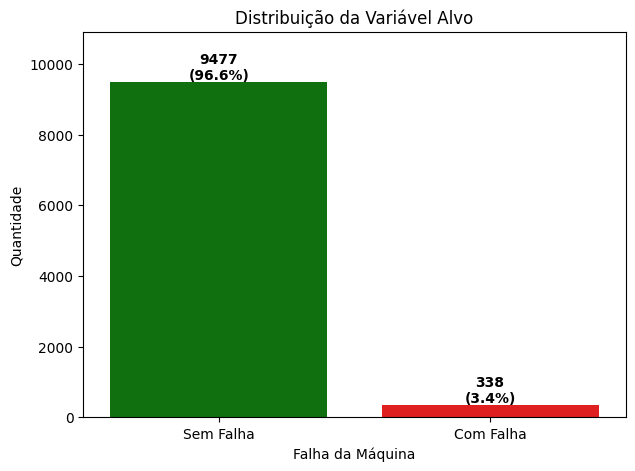

In [50]:
# 2. Gráfico de barras da variável alvo
# Verifica o desbalanceamento da base

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

plt.figure(figsize=(7,5))

ax = sns.countplot(
    x="falha_maquina",
    data=df_tratado
)

plt.title("Distribuição da Variável Alvo")
plt.xlabel("Falha da Máquina")
plt.ylabel("Quantidade")

# Alterar os nomes do eixo X
ax.set_xticklabels(["Sem Falha", "Com Falha"])

# Cálculo dos percentuais
total = len(df_tratado)

sem_falha = (df_tratado["falha_maquina"] == 0).sum()
com_falha = (df_tratado["falha_maquina"] == 1).sum()

perc_sem = sem_falha / total * 100
perc_com = com_falha / total * 100

# Valores sobre as barras
for barra in ax.patches:

    altura = barra.get_height()

    percentual = altura / total * 100

    ax.annotate(
        f"{int(altura)}\n({percentual:.1f}%)",
        (barra.get_x() + barra.get_width()/2, altura),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# Espaço para os rótulos
ax.set_ylim(0, max(df_tratado["falha_maquina"].value_counts()) * 1.15)

ax = sns.countplot(
    x="falha_maquina",
    data=df_tratado,
    palette=["green", "red"]
)

plt.show()

### Análise da distribuição da variável alvo

O gráfico evidencia um forte desbalanceamento entre as classes da variável alvo (falha_maquina). Aproximadamente 96,6% dos registros correspondem a máquinas que operaram sem falha, enquanto apenas cerca de 3,4% representam ocorrências de falha.

Esse desbalanceamento significa que o modelo terá muito mais exemplos da classe "Sem Falha" do que da classe "Com Falha" durante o treinamento. Como consequência, alguns algoritmos podem aprender a favorecer a classe majoritária, obtendo uma alta acurácia apenas por prever a maioria dos casos como "Sem Falha", sem necessariamente identificar corretamente as máquinas que realmente apresentam falhas.

Por isso, em problemas com dados desbalanceados, a acurácia isoladamente não é suficiente para avaliar a qualidade do modelo. É necessário analisar métricas que indiquem sua capacidade de detectar corretamente a classe minoritária, que neste caso representa as falhas das máquinas.




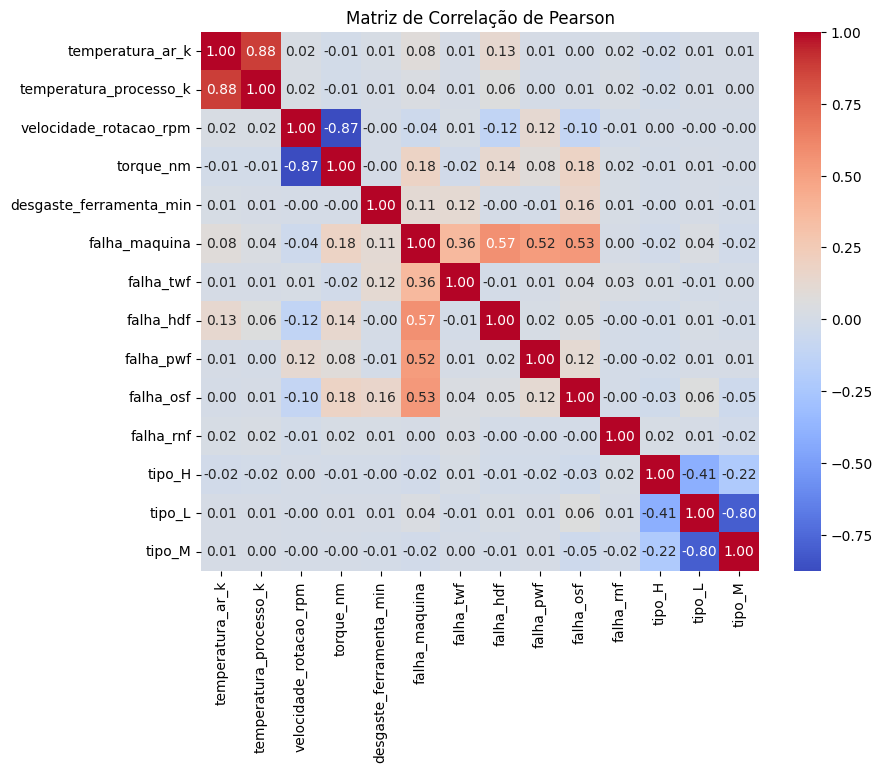

In [25]:
# Heatmap de Correlação (Pearson)

plt.figure(figsize=(9,7))

sns.heatmap(
    df_tratado.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação de Pearson")

plt.show()

## **Análise da Matriz de Correlação de Pearson**

A matriz de correlação de Pearson foi utilizada para identificar relações lineares entre as variáveis do conjunto de dados. Essa análise auxilia na identificação de atributos redundantes, possíveis problemas de multicolinearidade e variáveis potencialmente relevantes para a predição de falhas.


### 1. *Forte correlação entre as temperaturas*
'temperatura_ar_k' ... X ... 'temperatura_processo_k'
===== Correlação = 0,88

#### Interpretação: 
A temperatura do processo industrial pode acompanhar a temperatura ambiente. Quando a temperatura do ar aumenta, a temperatura do processo também tende a aumentar.



### 2. *Forte correlação negativa entre velocidade e torque*

'velocidade_rotacao_rpm' ... X ... 'torque_nm'  == Correlação = -0,87

#### Interpretação:
Existe uma relação física conhecida entre velocidade de rotação e torque.

maiores rotações tendem a exigir menor torque;
menores rotações geralmente estão associadas a maior torque.

Esse comportamento está relacionado ao equilíbrio entre potência, velocidade angular e torque.  


### 3. *Correlação das variáveis com a 'falha da máquina'*

A variável alvo é: ... 'falha_maquina'

As maiores correlações observadas foram:  

| Variável                   | Correlação  |  
|----------------------------|------------ |  
| **falha_hdf** | 0,58   |  
| **falha_osf** | 0,53   |  
| **falha_pwf** | 0,52   |  
| **falha_twf** | 0,36   |  
| **torque_nm** | 0,18   |  
| **desgaste_ferramenta_min** | 0,11 |  

#### Descrição das Variáveis

| Variável | Descrição |
|----------|-----------|
| **falha_hdf** | Superaquecimento (Heat Dissipation Failure) |
| **falha_osf** | Falha por tensão mecânica excessiva (Overstrain Failure) |
| **falha_pwf** | Falha por excesso de potência (Power Failure) |
| **falha_twf** | Falha por desgaste da ferramenta (Tool Wear Failure) |
| **torque_nm** | Torque aplicado ao motor (Nm) |
| **desgaste_ferramenta_min** | Tempo de utilização da ferramenta (minutos) |



#### Interpretação

Os maiores coeficientes de correlação estão associados às variáveis de falha específicas (HDF, OSF, PWF e TWF).
Essas variáveis representam diferentes modos de falha que contribuem diretamente para a ocorrência da falha geral da máquina.

Recomendação: se 'falha_maquina' deriva dessas variáveis, removê-las do conjunto de preditores antes do treinamento.
evitando que o modelo "descubra" a resposta durante o treinamento, produzindo métricas artificialmente elevadas.


### 4. *Baixa correlação das demais variáveis com a falha*

As variáveis:

temperatura_ar_k  
temperatura_processo_k  
velocidade_rotacao_rpm  

apresentaram correlações próximas de zero com a variável alvo.


### 5.*Variável 'desgaste da ferramenta'*

Correlação:  0,11

#### Interpretação:

Existe uma correlação positiva, porém fraca. O desgaste da ferramenta representa uma variável importante, pois pode atuar em conjunto com outras características para aumentar a probabilidade de falha.

 #### 6. Variável 'Tipo'

As variáveis abaixo não apresentaram correlação relevante com a variável alvo.

tipo_H  
tipo_L  
tipo_M  

#### Interpretação

O tipo de produto, isoladamente, parece exercer pouca influência sobre a ocorrência das falhas.

Entretanto, essa variável pode contribuir quando combinada com outras características durante o treinamento dos modelos.



### **Conclusão da análise**

forte correlação positiva entre as temperaturas do ar e do processo (0,88) e a forte correlação negativa entre velocidade de rotação e torque (-0,87), ambas compatíveis com o comportamento esperado de sistemas industriais. 

as maiores correlações com a variável 'falha_maquina' estão associadas às variáveis que representam modos específicos de falha (HDF, OSF, PWF e TWF). 

Esse resultado exige atenção durante a modelagem, pois essas variáveis podem introduzir vazamento de dados caso sejam utilizadas como atributos preditores. 
As demais variáveis apresentam correlação linear baixa com a variável alvo.  


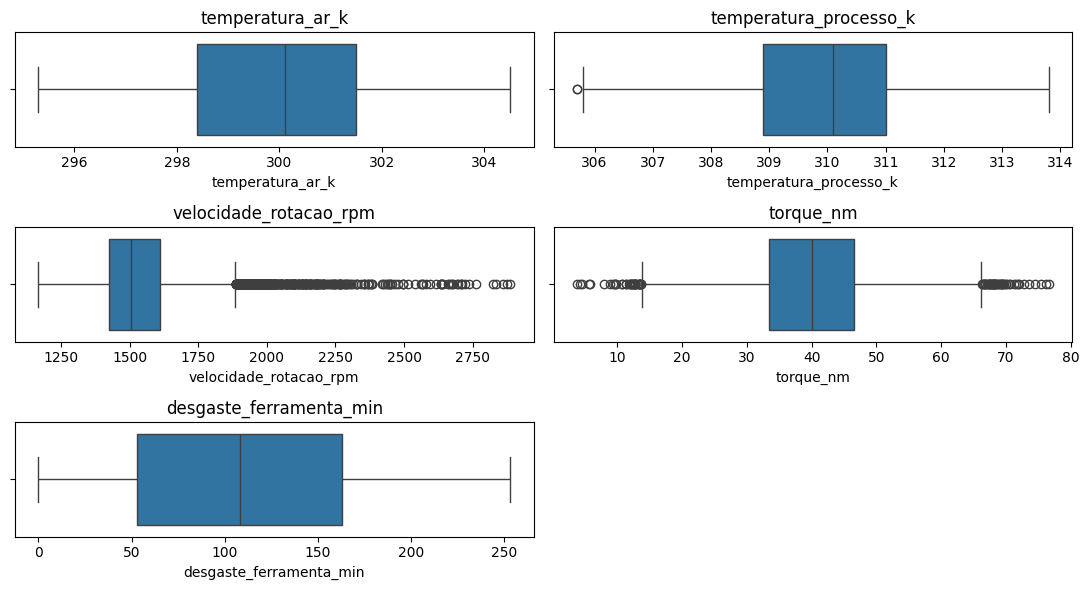

In [26]:
# boxplot das variáveis numéricas:
# identificar os 'outliers' com o grafico boxplot

colunas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

fig, axes = plt.subplots(3, 2, figsize=(11, 6))

axes = axes.flatten()

for i, coluna in enumerate(colunas):

    sns.boxplot(
        x=df_tratado[coluna],
        ax=axes[i]
    )

    axes[i].set_title(coluna)

# Remove o último espaço vazio
fig.delaxes(axes[5])

plt.tight_layout()

plt.show()

In [51]:
## analise de outliers

colunas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

for coluna in colunas:

    Q1 = df_tratado[coluna].quantile(0.25)
    Q3 = df_tratado[coluna].quantile(0.75)

    IQR = Q3 - Q1

    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR

    quantidade = (
        (df_tratado[coluna] < inferior) |
        (df_tratado[coluna] > superior)
    ).sum()

    print(f"{coluna}: {quantidade} outliers")

temperatura_ar_k: 0 outliers
temperatura_processo_k: 2 outliers
velocidade_rotacao_rpm: 435 outliers
torque_nm: 84 outliers
desgaste_ferramenta_min: 0 outliers


## analise histogramas e boxplots:

temperatura_ar_k        → não apresenta outliers relevantes;  
temperatura_processo_k  → praticamente sem outliers;  
velocidade_rotacao_rpm  → muitos valores classificados como outliers pelo IQR;  
torque_nm               → diversos outliers nas extremidades;  
desgaste_ferramenta_min → sem outliers significativos  





# Fase 3: Feature Engineering 

● Crie uma nova coluna numérica por meio de operação matemática entre 
colunas existentes, tratando os valores nulos previamente. 

● Sugestão (Manutenção): potencia = velocidade_rotacao_rpm * torque_nm
 
● (É permitida a criação de outra combinação matemática, desde que 
explicada no vídeo e documentada no notebook). 

In [59]:
# Criar nova variável potência

df_tratado["potencia"] = (
    df_tratado["velocidade_rotacao_rpm"] *
    df_tratado["torque_nm"]
)

# alem da potencia criei 2 novas features [delta_temperatura] e [carga_mecanica]

# Diferença de temperatura
df_tratado["delta_temperatura"] = (
    df_tratado["temperatura_processo_k"] -
    df_tratado["temperatura_ar_k"]
)

# Carga mecânica
df_tratado["carga_mecanica"] = (
    df_tratado["torque_nm"] *
    df_tratado["desgaste_ferramenta_min"]
)


# Visualizar

df_tratado[
    ["velocidade_rotacao_rpm",
     "torque_nm",
     "potencia",
     "delta_temperatura",
     "carga_mecanica",
     ]
].head()

,velocidade_rotacao_rpm,torque_nm,potencia,delta_temperatura,carga_mecanica
0,1551.0,42.8,66382.8,10.5,0.0
1,1408.0,46.3,65190.4,10.5,138.9
2,1498.0,49.4,74001.2,10.4,247.0
3,1504.0,40.1,60310.4,10.0,280.7
4,1408.0,40.0,56320.0,10.5,360.0


### justificativa inclusao das novas features  

Foi criada a variável potência, calculada como o produto entre a velocidade de rotação do eixo (velocidade_rotacao_rpm) e o torque aplicado (torque_nm). Essa variável representa uma característica derivada do processo de operação da máquina e pode auxiliar os algoritmos de aprendizado de máquina na identificação de padrões associados à ocorrência de falhas, agregando informação relevante ao conjunto de atributos.

Além da variável potência, foram criadas duas novas características derivadas.  
 A variável delta_temperatura representa a diferença entre a temperatura do processo e a temperatura ambiente, podendo indicar condições de superaquecimento ou problemas na dissipação de calor.  

 Já a variável carga_mecanica combina o torque aplicado ao motor com o desgaste acumulado da ferramenta, representando o esforço mecânico ao qual o equipamento está submetido.  

 Essas novas variáveis foram criadas para fornecer informações adicionais ao modelo de aprendizado de máquina, possibilitando a identificação de padrões mais complexos associados à ocorrência de falhas.

In [ ]:
# confirmar a existencia de dados nulos

df_tratado.info()

# Fase 4: Divisão e Balanceamento dos Dados 

● Separe as variáveis preditoras (X) da variável alvo (y).

● Divida os dados em treino (80%) e teste (20%) utilizando o parâmetro 
stratify=y. 

● Aplique uma técnica de reamostragem (SMOTE ou Random Under 
Sampling) exclusivamente nos dados de treino para evitar o vazamento de 
dados (Data Leakage). 

# Fase 5: Escalonamento de Variáveis (StandardScaler) 

● Aplique o StandardScaler apenas nas variáveis contínuas destinadas ao 
modelo KNN (utilizando fit_transform no treino e transform no teste). 

● Mantenha os dados da Árvore de Decisão sem escalonamento, justificando 
no código o motivo de o algoritmo ser imune à escala dos atributos. 

# Fase 6: Ajuste de Parâmetros e Combate ao Overfitting 

● No KNN: Treine o modelo variando o parâmetro n_neighbors (K) por no 
mínimo 3 valores ímpares (ex: K = 3, 5, 7) e registre a acurácia no treino e no 
teste. 

● Na Árvore: Treine o modelo variando o parâmetro max_depth por no 
mínimo 3 limites (ex: 3, 5 e None) e registre a acurácia no treino e no teste. 

● Insira um texto identificando em quais pontos ocorreu o overfitting e qual 
configuração garantiu a estabilidade no teste. 

# Fase 7: Avaliação da Acurácia e Veredito Final 

● Calcule e exiba a acurácia final do melhor KNN e da melhor árvore de 
decisão utilizando os dados de teste. 

● Compare as taxas de acerto e escreva uma conclusão justificando qual 
modelo apresentou o desempenho superior no teste e deve ser adotado 
pela empresa. 